In [46]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./graph_preset.mplstyle')
import matplotlib.gridspec as gridspec
from scipy.stats.qmc import LatinHypercube, scale
from scipy.stats import norm

--- Strategy Selected: LCB ---
--- Starting Optimization Loop (30 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | 0.340434   | -0.548044   | [0.63]
2     | 0.340434   | -0.815392   | [0.69]
3     | 0.340434   | 0.530217   | [1.00]
4     | 0.340434   | -0.940631   | [0.69]
5     | 0.340434   | -0.919269   | [0.69]
6     | 0.340434   | -0.851509   | [0.69]
7     | 0.340434   | -0.856083   | [0.69]
8     | 0.340434   | -0.840477   | [0.69]
9     | 0.340434   | -0.928703   | [0.69]
10    | 0.340434   | -0.901086   | [0.69]
11    | 0.340434   | -0.898151   | [0.69]
12    | 0.340434   | -0.975020   | [0.69]
13    | 0.340434   | -0.938203   | [0.69]
14    | 0.340434   | -0.880591   | [0.69]
15    | 0.340434   | -0.817255   | [0.69]
16    | 0.340434   | -0.843847   | [0.70]
17    | 0.340434   | -0.838943   | [0.68]
18    | 0.340434   | -0.929830   | [0.70]
19    | 0.340434   | -0.875463   | [0.70]
20    | 0.340434   | 

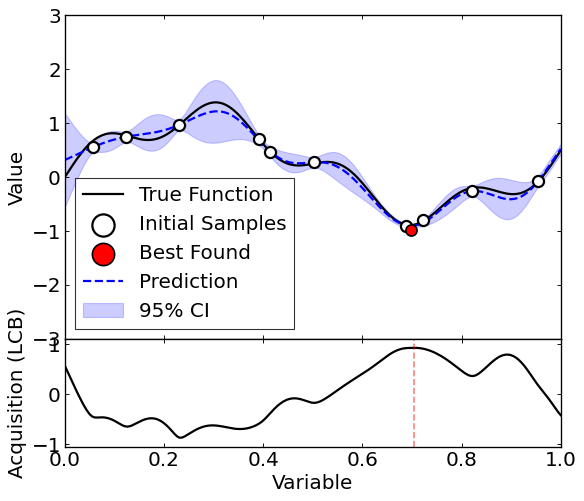

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -0.982657
At location: x = [0.69849246]


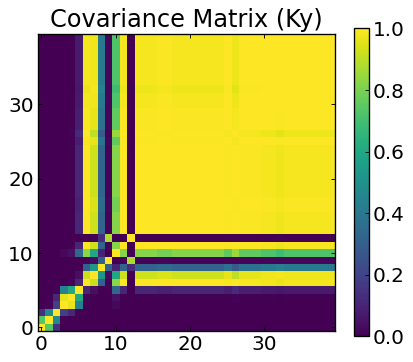

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats.qmc import LatinHypercube, scale
from scipy.stats import norm

# -------------------- 1. Core Functions --------------------

def rbf_kernel(x1: np.ndarray, x2: np.ndarray, gamma: float) -> np.ndarray:
    sqdist = (
        np.sum(x1**2, 1).reshape(-1, 1) -
        2 * np.dot(x1, x2.T) +
        np.sum(x2**2, 1)
    )
    return np.exp(-gamma * sqdist)

# Alias to match the function signature used in 2D example
kernel = rbf_kernel

def test_1D(x: np.ndarray) -> np.ndarray:
    """True function to be approximated."""
    return (
        np.sin(2 * np.pi * x) +
        0.3 * np.sin(8 * np.pi * x) +
        0.5 * x
    )

def LHSsampler(dims, n_samples, lower_bounds, upper_bounds):
    sampler = LatinHypercube(d=dims, seed=42)
    samples_continuous = sampler.random(n=n_samples)
    X_initial = scale(samples_continuous, lower_bounds, upper_bounds)
    return X_initial

# -------------------- 2. Helper Functions (Acquisition) --------------------

def get_posterior(x_new, X_sample, y_sample, Ky_opt_inv, length_scale):
    x_new = x_new.reshape(1, -1)
    # length_scale here acts as gamma
    K_star = kernel(X_sample, x_new, length_scale)
    mu_post = K_star.T @ Ky_opt_inv @ y_sample
    K_star_star = 1.0 
    cov_post = K_star_star - K_star.T @ Ky_opt_inv @ K_star
    s2_post = np.maximum(0, cov_post.item())
    return mu_post.item(), np.sqrt(s2_post)

def expected_improvement(x_new, X_sample, y_sample, Ky_opt_inv, length_scale, xi=0.01):
    mu, sigma = get_posterior(x_new, X_sample, y_sample, Ky_opt_inv, length_scale)
    y_best = np.min(y_sample)
    if sigma == 0: return 0
    imp = y_best - mu - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

def lower_confidence_bound(x_new, X_sample, y_sample, Ky_opt_inv, length_scale, kappa=2.0):
    """
    Lower Confidence Bound (LCB).
    We return negative LCB so that argmax finds the minimum of (mu - kappa*sigma).
    """
    mu, sigma = get_posterior(x_new, X_sample, y_sample, Ky_opt_inv, length_scale)
    return -mu + kappa * sigma

def plot_covariance_matrix(K):
    fig, ax = plt.subplots(figsize=(6, 5), dpi=80)
    im = ax.imshow(K, cmap="viridis", vmin=0, vmax=1, origin="lower")
    ax.set_title("Covariance Matrix (Ky)")
    fig.colorbar(im, ax=ax)
    plt.show()

# -------------------- 3. Settings --------------------

# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 30
xi = 0.01

# Grid for plotting & searching
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 4. Initialization --------------------

# Generate samples using Latin Hypercube Sampling
X_train = LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])] # Sort initial for neatness
y_train = test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep a copy of initial data for plotting distinction
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 5. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Calculate Kernel Matrix and Inverse
    K = kernel(X_train, X_train, gamma)
    Ky = K + noise_var * np.identity(len(X_train))
    
    try:
        Ky_inv = np.linalg.inv(Ky)
    except np.linalg.LinAlgError:
        Ky_inv = np.linalg.inv(Ky + 1e-8 * np.identity(len(X_train)))

    # 2. Calculate Acquisition for all grid points
    # Using ALIAS 'acq_func' with kwargs
    acq_list = [acq_func(x, X_train, y_train, Ky_inv, gamma, **acq_params) for x in X_grid]
    acq_array = np.array(acq_list)
    
    # 3. Select Next Point
    best_idx = np.argmax(acq_array)
    x_new = X_grid[best_idx]
    
    # 4. Evaluate True Function (add noise)
    y_new = test_1D(x_new).reshape(1, -1) + np.random.normal(0, noise_std, (1, 1))

    # 5. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 6. Final Calculation for Plotting --------------------

# Re-calculate GP Posterior on the grid using ALL data
K = kernel(X_train, X_train, gamma)
Ky = K + noise_var * np.identity(len(X_train))
try:
    Ky_inv = np.linalg.inv(Ky)
except:
    Ky_inv = np.linalg.inv(Ky + 1e-8 * np.identity(len(X_train)))

# Get prediction and acquisition values for the final state
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = get_posterior(x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    # Calculate acquisition for plotting
    acq_final_list.append(acq_func(x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post_1d = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point found so far
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# -------------------- 7. Visualization --------------------
fig = plt.figure(figsize=(8, 7), dpi=80)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0)

# Top plot: GP Prediction
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(X_grid, test_1D(X_grid), 'k-', label='True Function', linewidth=2)

# Plot Initial Samples (White dots)
ax1.scatter(X_init_plot, y_init_plot, c='w', s=100, alpha=1, edgecolors='k', lw=2, label='Initial Samples', zorder=3)

# Plot Best Found Point (Red Star)
ax1.scatter(best_x, best_y, c='red', s=100, marker='o', alpha=1, edgecolors='k', lw=1.5, label='Best Found', zorder=5)

# Plot GP Prediction
ax1.plot(X_grid, mu_post_1d, 'b--', label='Prediction', linewidth=2)
ax1.fill_between(X_grid.ravel(),
                 (mu_post_1d - 1.96 * s_post),
                 (mu_post_1d + 1.96 * s_post),
                 color="blue", alpha=0.2, label="95% CI")

ax1.set_ylabel('Value')
ax1.legend(loc='lower left')
ax1.grid(False)
ax1.set_xlim(0, 1)
ax1.set_ylim(-3, 3)
plt.setp(ax1.get_xticklabels(), visible=False)

# Bottom plot: Acquisition Function
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax2.plot(X_grid, acq_final, 'k-', linewidth=2)

# Highlight max Acquisition point
next_sample_index = np.argmax(acq_final)
next_sample_x = X_grid.ravel()[next_sample_index]
ax2.axvline(next_sample_x, color='red', linestyle='--', alpha=0.5)

ax2.set_xlabel('Variable')
ax2.set_ylabel(f'Acquisition ({STRATEGY})')
ax2.grid(False)
ax2.set_xlim(0, 1)

# Dynamic Y-limit to handle both EI (near 0) and LCB (larger values)
y_min = np.min(acq_final)
y_max = np.max(acq_final)
if STRATEGY == "EI":
    # Keep the user's preferred tight limits for EI if relevant, or use dynamic
    ax2.set_ylim(-0.003, max(0.013, y_max*1.1))
else:
    # Dynamic limits for LCB
    margin = (y_max - y_min) * 0.1
    ax2.set_ylim(y_min - margin, y_max + margin)

plt.show()

# -------------------- 8. Final Result & Covariance Plot --------------------
print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

# Calculate final Kernel matrix for plotting
K_final = kernel(X_train, X_train, gamma)
plot_covariance_matrix(K_final)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats.qmc import LatinHypercube, scale
from scipy.stats import norm

# -------------------- 1. Core Functions --------------------

def rbf_kernel(x1: np.ndarray, x2: np.ndarray, gamma: float) -> np.ndarray:
    sqdist = (
        np.sum(x1**2, 1).reshape(-1, 1) -
        2 * np.dot(x1, x2.T) +
        np.sum(x2**2, 1)
    )
    return np.exp(-gamma * sqdist)

# Alias
kernel = rbf_kernel

def ackley_2d(x: np.ndarray) -> np.ndarray:
    """Ackley function (2D). Global Minimum: f(0,0) = 0."""
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x1 = x[:, 0]
    x2 = x[:, 1]
    a = 20; b = 0.2; c = 2 * np.pi
    
    sum_sq = x1**2 + x2**2
    cos_sum = np.cos(c * x1) + np.cos(c * x2)
    
    term1 = -a * np.exp(-b * np.sqrt(0.5 * sum_sq))
    term2 = -np.exp(0.5 * cos_sum)
    
    return term1 + term2 + a + np.exp(1)

def LHSsampler(dims, n_samples, lower_bounds, upper_bounds):
    sampler = LatinHypercube(d=dims, seed=42)
    samples_continuous = sampler.random(n=n_samples)
    X_initial = scale(samples_continuous, lower_bounds, upper_bounds)
    return X_initial

# -------------------- 2. Helper Functions (Optimization & Math) --------------------

def get_posterior(x_new, X_sample, y_sample, Ky_opt_inv, gamma):
    x_new = x_new.reshape(1, -1)
    K_star = kernel(X_sample, x_new, gamma)
    mu_post = K_star.T @ Ky_opt_inv @ y_sample
    K_star_star = 1.0 
    cov_post = K_star_star - K_star.T @ Ky_opt_inv @ K_star
    s2_post = np.maximum(0, cov_post.item())
    return mu_post.item(), np.sqrt(s2_post)

def expected_improvement(x_new, X_sample, y_sample, Ky_opt_inv, gamma, xi=0.01):
    mu, sigma = get_posterior(x_new, X_sample, y_sample, Ky_opt_inv, gamma)
    y_best = np.min(y_sample)
    if sigma == 0: return 0.0
    imp = y_best - mu - xi
    Z = imp / sigma
    ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# --- New: Wrapper for minimizing Negative EI ---
def negative_expected_improvement(x_new, X_sample, y_sample, Ky_opt_inv, gamma, xi=0.01):
    # minimize expects a scalar return
    return -expected_improvement(x_new, X_sample, y_sample, Ky_opt_inv, gamma, xi)

# --- New: Acquisition Function Optimizer ---
def optimize_acquisition(X_sample, y_sample, Ky_opt_inv, gamma, lower_bounds, upper_bounds, DIMS):
    best_acq_value = np.inf # We represent this as minimizing negative EI, so looking for min
    best_x = None
    n_restarts = 10 # Number of random starting points for the optimizer
    bounds = list(zip(lower_bounds, upper_bounds))

    for i in range(n_restarts):
        x0 = np.random.uniform(lower_bounds, upper_bounds, DIMS)
        res = minimize(
            fun=negative_expected_improvement, 
            x0=x0,
            args=(X_sample, y_sample, Ky_opt_inv, gamma),
            bounds=bounds, 
            method='L-BFGS-B'
        )
        # We want the minimum negative EI (which is max EI)
        if res.success and res.fun < best_acq_value:
            best_acq_value = res.fun
            best_x = res.x
    
    if best_x is None:
        print("  > WARNING: Acquisition optimization failed. Using a random point.")
        best_x = np.random.uniform(lower_bounds, upper_bounds, DIMS)
    
    return best_x, -best_acq_value # Return max EI value for logging

# --- New: Negative Log Marginal Likelihood for Hyperparam Tuning ---
def negative_log_marginal_likelihood(params, X, y, noise_var):
    gamma = params[0]
    # Bound constraint handling inside function (optional, but good for safety)
    if gamma <= 0: return np.inf
    
    n = len(X)
    K = kernel(X, X, gamma)
    Ky = K + noise_var * np.identity(n) + 1e-6 * np.identity(n) # Jitter
    
    try:
        L = np.linalg.cholesky(Ky)
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        log_det_Ky = 2 * np.sum(np.log(np.diag(L)))
        likelihood = 0.5 * (y.T @ alpha) + 0.5 * log_det_Ky + 0.5 * n * np.log(2 * np.pi)
        return likelihood.item()
    except np.linalg.LinAlgError:
        return np.inf

def plot_covariance_matrix(K):
    fig, ax = plt.subplots(figsize=(6, 5), dpi=80)
    im = ax.imshow(K, cmap="viridis", vmin=0, vmax=1, origin="lower") 
    ax.set_title("Covariance Matrix (Ky)")
    fig.colorbar(im, ax=ax)
    plt.show()

# -------------------- 3. Settings --------------------

dims = 2
lower_bounds = [-2.0, -2.0]
upper_bounds = [2.0, 2.0]

# Initial Gamma (will be updated by optimization)
current_gamma = 1.0  
noise_std = 0.0
noise_var = noise_std ** 2

n_init = 50
n_iter = 500
xi = 0.01

# -------------------- 4. Bayesian Optimization Loop --------------------

print(f"--- Initializing with {n_init} LHS samples ---")
X_train = LHSsampler(dims, n_init, lower_bounds, upper_bounds)
y_train = ackley_2d(X_train).reshape(-1, 1)

print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'Gamma':<8} | {'New x (approx)'}")
print("-" * 75)

for i in range(n_iter):
    
    # --- Step A: Optimize Hyperparameters (Gamma) ---
    # We define bounds for gamma. Since Ackley is wiggly, gamma might need to be large.
    # Bounds: [0.1, 50.0] roughly.
    res_hyp = minimize(
        negative_log_marginal_likelihood, 
        x0=[current_gamma], 
        args=(X_train, y_train, noise_var),
        bounds=[(0.1, 100.0)], # Allow wider range for Ackley
        method='L-BFGS-B'
    )
    
    if res_hyp.success:
        current_gamma = res_hyp.x[0]
    
    # --- Step B: Calculate Kernel Matrix (with new gamma) ---
    K = kernel(X_train, X_train, current_gamma)
    Ky = K + noise_var * np.identity(len(X_train)) + 1e-6 * np.identity(len(X_train))
    
    try:
        Ky_inv = np.linalg.inv(Ky)
    except np.linalg.LinAlgError:
        Ky_inv = np.linalg.inv(Ky + 1e-5 * np.identity(len(X_train)))

    # --- Step C: Optimize Acquisition Function ---
    x_new, _ = optimize_acquisition(
        X_train, y_train, Ky_inv, current_gamma, 
        lower_bounds, upper_bounds, dims
    )
    
    # --- Step D: Evaluate True Function ---
    y_new = ackley_2d(x_new.reshape(1, -1))

    # --- Step E: Update Data ---
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])

    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | {current_gamma:.4f}   | [{x_new[0]:.2f}, {x_new[1]:.2f}]")

# -------------------- 5. Final Result & Visualization --------------------
best_idx_final = np.argmin(y_train)
print("-" * 75)
print(f"Optimization Finished.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")
print(f"At location: x = {X_train[best_idx_final]}")

print("--- Recalculating Inverse Matrix for Visualization ---")
K = kernel(X_train, X_train, current_gamma)
Ky = K + noise_var * np.identity(len(X_train)) + 1e-6 * np.identity(len(X_train))
try:
    Ky_inv = np.linalg.inv(Ky)
except np.linalg.LinAlgError:
    Ky_inv = np.linalg.inv(Ky + 1e-5 * np.identity(len(X_train)))

# Visualization (Create grid ONLY for plotting final state)
grid_res = 50
x1_grid = np.linspace(lower_bounds[0], upper_bounds[0], grid_res)
x2_grid = np.linspace(lower_bounds[1], upper_bounds[1], grid_res)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
X_grid_plot = np.column_stack([X1.ravel(), X2.ravel()])

# Calculate final prediction for grid
mu_list = []
for x in X_grid_plot:
    m, _ = get_posterior(x, X_train, y_train, Ky_inv, current_gamma)
    mu_list.append(m)
mu_grid = np.array(mu_list).reshape(grid_res, grid_res)

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2)

# Plot 1: GP Posterior Mean
ax1 = fig.add_subplot(gs[0, 0])
c1 = ax1.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, label='Predicted Value')
ax1.scatter(X_train[:, 0], X_train[:, 1], c='white', edgecolors='black', s=30, label='Samples')
ax1.scatter(X_train[best_idx_final, 0], X_train[best_idx_final, 1], c='red', marker='*', s=200, label='Best')
ax1.set_title(f'Posterior Mean (Gamma={current_gamma:.2f})')
ax1.legend()

# Plot 2: Covariance Matrix
ax2 = fig.add_subplot(gs[0, 1])
K_final = kernel(X_train, X_train, current_gamma)
im = ax2.imshow(K_final, cmap="viridis", vmin=0, vmax=1, origin="lower")
ax2.set_title("Final Covariance Matrix")
fig.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

--- Initializing with 50 LHS samples ---
--- Starting Optimization Loop (500 iterations) ---
Iter  | Best y     | New y      | Gamma    | New x (approx)
---------------------------------------------------------------------------
1     | 1.546883   | 6.791510   | 2.1450   | [2.00, 1.26]
2     | 1.546883   | 5.633673   | 2.1086   | [0.04, -1.68]
3     | 0.561413   | 0.561413   | 2.1016   | [0.10, -0.04]
4     | 0.561413   | 7.563305   | 2.4499   | [-1.45, 1.97]
5     | 0.561413   | 5.881068   | 2.4399   | [0.68, -1.33]
6     | 0.561413   | 5.406344   | 2.4207   | [-1.94, 0.15]
7     | 0.561413   | 6.023929   | 2.4162   | [-1.99, 1.14]
8     | 0.561413   | 6.004700   | 2.3907   | [-0.19, 1.70]
9     | 0.561413   | 6.517015   | 2.3729   | [-0.68, 1.98]
10    | 0.561413   | 7.576150   | 2.3765   | [-1.90, -1.48]
11    | 0.561413   | 6.665911   | 2.3428   | [1.89, 0.55]
12    | 0.561413   | 6.209926   | 2.3331   | [0.77, -2.00]
13    | 0.471418   | 0.471418   | 2.3271   | [-0.09, 0.00]
14   

KeyboardInterrupt: 